In [ ]:
!nvidia-smi

Thu Dec 18 20:16:03 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             54W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
!pip install wandb tensorflow statsmodels

In [ ]:
"""
============================================================
LSTM Multi-Output Forecasting Pipeline (FINAL)
Project: NYC Citi Bike Congestion Intelligence
Course: CS559
Author: Milan Chandiramani
============================================================

This script:
- Uses SAME engineered hourly dataset as XGBoost
- Builds sequential windows for LSTM
- Trains a GLOBAL multi-output LSTM model (GPU accelerated)
- Predicts: avail_bikes, avail_docks, occupancy
- Evaluates RMSE, MAE, R2, MAPE
- Generates comparable plots
- Logs to Weights & Biases
- Saves trained model + scalers
"""

# ============================================================
# 0. IMPORTS + GPU SETUP
# ============================================================

import os
import glob
import math
import numpy as np
import pandas as pd
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import wandb

from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

# ---------- GPU ----------
tf.config.optimizer.set_jit(True)
for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(gpu, True)

print("✅ GPUs:", tf.config.list_physical_devices("GPU"))


# ============================================================
# 1. WANDB SETUP
# ============================================================

wandb.login(key = "8167d8f0f429b191c4958866ae4a9ef380ae62ef")

run = wandb.init(
    project="cs559",
    name=f"lstm_{datetime.now().strftime('%Y%m%d_%H%M%S')}",
    config={
        "model": "LSTM MultiOutput",
        "window": 48,
        "epochs": 54,
        "batch_size": 1024,
        "lstm_units": 128,
        "learning_rate": 3e-4,
        "dropout": 0.2
    }
)

CFG = run.config


# ============================================================
# 2. LOAD DATA
# ============================================================
SPLIT_DATE = "2017-05-01"
DATA_DIR = "/content/drive/MyDrive/" #"data"   # <-- change if needed
csv_files = glob.glob(os.path.join(DATA_DIR, "CitiBikeDataMyBusProcessed_occupancyfix.csv"))
if not csv_files:
    raise FileNotFoundError("❌ No CSV files found in data directory")
df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

print("Timestamp range:", df["timestamp"].min(), "-", df["timestamp"].max())

df["dock_name"] = (
    df["dock_name"].astype(str)
    .str.strip().str.strip('"').str.strip("'")
)

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values(["dock_name", "timestamp"])


# ============================================================
# 3. FEATURE ENGINEERING (IDENTICAL)
# ============================================================

FEATURES = [
    "_lat", "_long", "tot_docks",
    "hour", "dayofweek", "month", "is_weekend", "is_holiday",
    "lag_occ_1", "lag_occ_24", "roll_occ_3", "roll_occ_24",
    "temperature_2m", "relative_humidity_2m",
    "precipitation", "wind_speed_10m"
]

TARGETS = ["avail_bikes", "avail_docks", "occupancy"]

def build_global_hourly(df):
    hourly = (
        df.set_index("timestamp")
        .groupby("dock_name")
        .resample("1H")
        .mean()
        .reset_index()
    )

    hourly["hour"] = hourly["timestamp"].dt.hour
    hourly["dayofweek"] = hourly["timestamp"].dt.dayofweek
    hourly["month"] = hourly["timestamp"].dt.month
    hourly["is_weekend"] = hourly["dayofweek"].isin([5, 6]).astype(int)

    hourly["lag_occ_1"] = hourly.groupby("dock_name")["occupancy"].shift(1)
    hourly["lag_occ_24"] = hourly.groupby("dock_name")["occupancy"].shift(24)

    hourly["roll_occ_3"] = (
        hourly.groupby("dock_name")["occupancy"]
        .rolling(3).mean().reset_index(0, drop=True)
    )

    hourly["roll_occ_24"] = (
        hourly.groupby("dock_name")["occupancy"]
        .rolling(24).mean().reset_index(0, drop=True)
    )

    return hourly.dropna()

hourly_df = build_global_hourly(df)
hourly_df = hourly_df.reset_index(drop=True)

print("✅ Hourly rows:", len(hourly_df))


# ============================================================
# 4. TRAIN / TEST SPLIT (MATCH XGBOOST)
# ============================================================

SPLIT_DATE = "2017-05-01"
train_df = hourly_df[hourly_df["timestamp"] < SPLIT_DATE].copy()
test_df  = hourly_df[hourly_df["timestamp"] >= SPLIT_DATE].copy()

X_train_raw = train_df[FEATURES].values
y_train_raw = train_df[TARGETS].values

X_test_raw  = test_df[FEATURES].values
y_test_raw  = test_df[TARGETS].values

# print("Unique stations in test set:", test_df["dock_name"].unique())


# ============================================================
# 5. SCALING (CRITICAL FOR LSTM)
# ============================================================

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train_raw)
X_test  = x_scaler.transform(X_test_raw)

y_train = y_scaler.fit_transform(y_train_raw)
y_test  = y_scaler.transform(y_test_raw)

joblib.dump(x_scaler, "lstm_x_scaler.pkl")
joblib.dump(y_scaler, "lstm_y_scaler.pkl")
wandb.save("lstm_x_scaler.pkl")
wandb.save("lstm_y_scaler.pkl")


# ============================================================
# 6. WINDOW CREATION (SAFE, FINAL VERSION)
# ============================================================

WINDOW = CFG.window

def make_windows(X, y, window):
    X_seq, y_seq = [], []
    for i in range(len(X) - window):
        X_seq.append(X[i:i+window])
        y_seq.append(y[i+window])
    return np.array(X_seq), np.array(y_seq)

Xtr_seq, ytr_seq = make_windows(X_train, y_train, WINDOW)
Xte_seq, yte_seq = make_windows(X_test,  y_test,  WINDOW)

assert Xtr_seq.shape[0] == ytr_seq.shape[0]
assert Xte_seq.shape[0] == yte_seq.shape[0]

print("Train seq:", Xtr_seq.shape, ytr_seq.shape)
print("Test  seq:", Xte_seq.shape, yte_seq.shape)


# ============================================================
# 7. LSTM MODEL
# ============================================================

model = models.Sequential([
    layers.Input(shape=(WINDOW, Xtr_seq.shape[-1])),
    layers.LSTM(CFG.lstm_units, return_sequences=True),
    layers.Dropout(CFG.dropout),
    layers.LSTM(CFG.lstm_units),
    layers.Dropout(CFG.dropout),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(TARGETS))
])

model.compile(
    optimizer=optimizers.Adam(CFG.learning_rate),
    loss=tf.keras.losses.Huber(delta = 1.0),
    metrics=["mae"]
)

model.summary()


# ============================================================
# 8. TRAINING
# ============================================================

history = model.fit(
    Xtr_seq, ytr_seq,
    validation_data=(Xte_seq, yte_seq),
    epochs=CFG.epochs,
    batch_size=CFG.batch_size,
    callbacks=[
        callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        wandb.keras.WandbMetricsLogger()
    ],
    verbose=1
)


# ============================================================
# 9. PREDICTION + INVERSE SCALE
# ============================================================

y_pred_scaled = model.predict(Xte_seq)
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_scaler.inverse_transform(yte_seq)


# ============================================================
# 10. METRICS (SAME AS XGBOOST)
# ============================================================

def safe_mape(y_true, y_pred):
    mask = np.abs(y_true) > 1e-6
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

metrics = {}
for i, col in enumerate(TARGETS):
    metrics[f"lstm_{col}_RMSE"] = math.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
    metrics[f"lstm_{col}_MAE"]  = mean_absolute_error(y_true[:, i], y_pred[:, i])
    metrics[f"lstm_{col}_R2"]   = r2_score(y_true[:, i], y_pred[:, i])
    metrics[f"lstm_{col}_MAPE"] = safe_mape(y_true[:, i], y_pred[:, i])

wandb.log(metrics)

print("\n📌 LSTM Metrics")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")


# ============================================================
# 11. SAVE MODEL
# ============================================================

MODEL_DIR = "model_export"
os.makedirs(MODEL_DIR, exist_ok=True)

# ---- Save model + scalers locally ----
model.save(f"{MODEL_DIR}/lstm_multioutput.keras")
model.save(f"{MODEL_DIR}/lstm_multioutput.h5")

joblib.dump(x_scaler, f"{MODEL_DIR}/lstm_x_scaler.pkl")
joblib.dump(y_scaler, f"{MODEL_DIR}/lstm_y_scaler.pkl")

# ---- Create a W&B Artifact ----
artifact = wandb.Artifact(
    name="lstm-multioutput-model",
    type="model",
    description="Global multi-output LSTM for Citi Bike availability forecasting",
    metadata={
        "window": int(CFG.window),
        "lstm_units": int(CFG.lstm_units),
        "dropout": float(CFG.dropout),
        "learning_rate": float(CFG.learning_rate),
        "epochs": int(CFG.epochs),
        "batch_size": int(CFG.batch_size),
        "targets": TARGETS,
        "features": FEATURES,
    }
)

# ---- Add all exported files ----
artifact.add_dir(MODEL_DIR)

# ---- Log to WandB ----
run.log_artifact(artifact)

print("📦 Uploaded LSTM model + scalers as a versioned W&B artifact")




✅ GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mc77chand (mc77chand-stevens-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Timestamp range: 2015-03-01 00:07:00 - 2019-04-30 17:34:00


/tmp/ipython-input-2870353836.py:116: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H")


✅ Hourly rows: 2392762


...

 Trainable params: 222,723 (870.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/54
618/618 ━━━━━━━━━━━━━━━━━━━━ 37s 45ms/step - loss: 0.1615 - mae: 0.4080 - val_loss: 0.0760 - val_mae: 0.2494
Epoch 2/54
618/618 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - loss: 0.0664 - mae: 0.2353 - val_loss: 0.0668 - val_mae: 0.2295
Epoch 3/54
618/618 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.0562 - mae: 0.2110 - val_loss: 0.0621 - val_mae: 0.2165
Epoch 4/54
618/618 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.0507 - mae: 0.1971 - val_loss: 0.0598 - val_mae: 0.2115
Epoch 5/54
618/618 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.0480 - mae: 0.1898 - val_loss: 0.0602 - val_mae: 0.2116
Epoch 6/54
618/618 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.0466 - mae: 0.1858 - val_loss: 0.0601 - val_mae: 0.2128
Epoch 7/54
618/618 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.0456 - mae: 0.1832 - val_loss: 0.0595 - val_mae: 0.2106
Epoch 8/54
618/618 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.0445 - mae: 0.1807 - val_loss: 0.0591 - val_mae: 0.2101
Epoch 9/54
618/618 ━━━━━━━━━━━━━━━━━━━━ 

wandb: Adding directory to artifact (model_export)... Done. 0.0s



📌 LSTM Metrics
lstm_avail_bikes_RMSE: 3.7547
lstm_avail_bikes_MAE: 2.0973
lstm_avail_bikes_R2: 0.8616
lstm_avail_bikes_MAPE: 39.1327
lstm_avail_docks_RMSE: 4.3085
lstm_avail_docks_MAE: 2.4926
lstm_avail_docks_R2: 0.8841
lstm_avail_docks_MAPE: 31.8992
lstm_occupancy_RMSE: 0.1111
lstm_occupancy_MAE: 0.0651
lstm_occupancy_R2: 0.8667
lstm_occupancy_MAPE: 38.9395
📦 Uploaded LSTM model + scalers as a versioned W&B artifact


In [ ]:
test_df.columns

Index(['dock_name', 'timestamp', '_lat', '_long', 'avail_bikes', 'avail_docks',
       'tot_docks', 'occupancy', 'is_holiday', 'is_weekend', 'temperature_2m',
       'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'hour',
       'dayofweek', 'month', 'lag_occ_1', 'lag_occ_24', 'roll_occ_3',
       'roll_occ_24'],
      dtype='object')

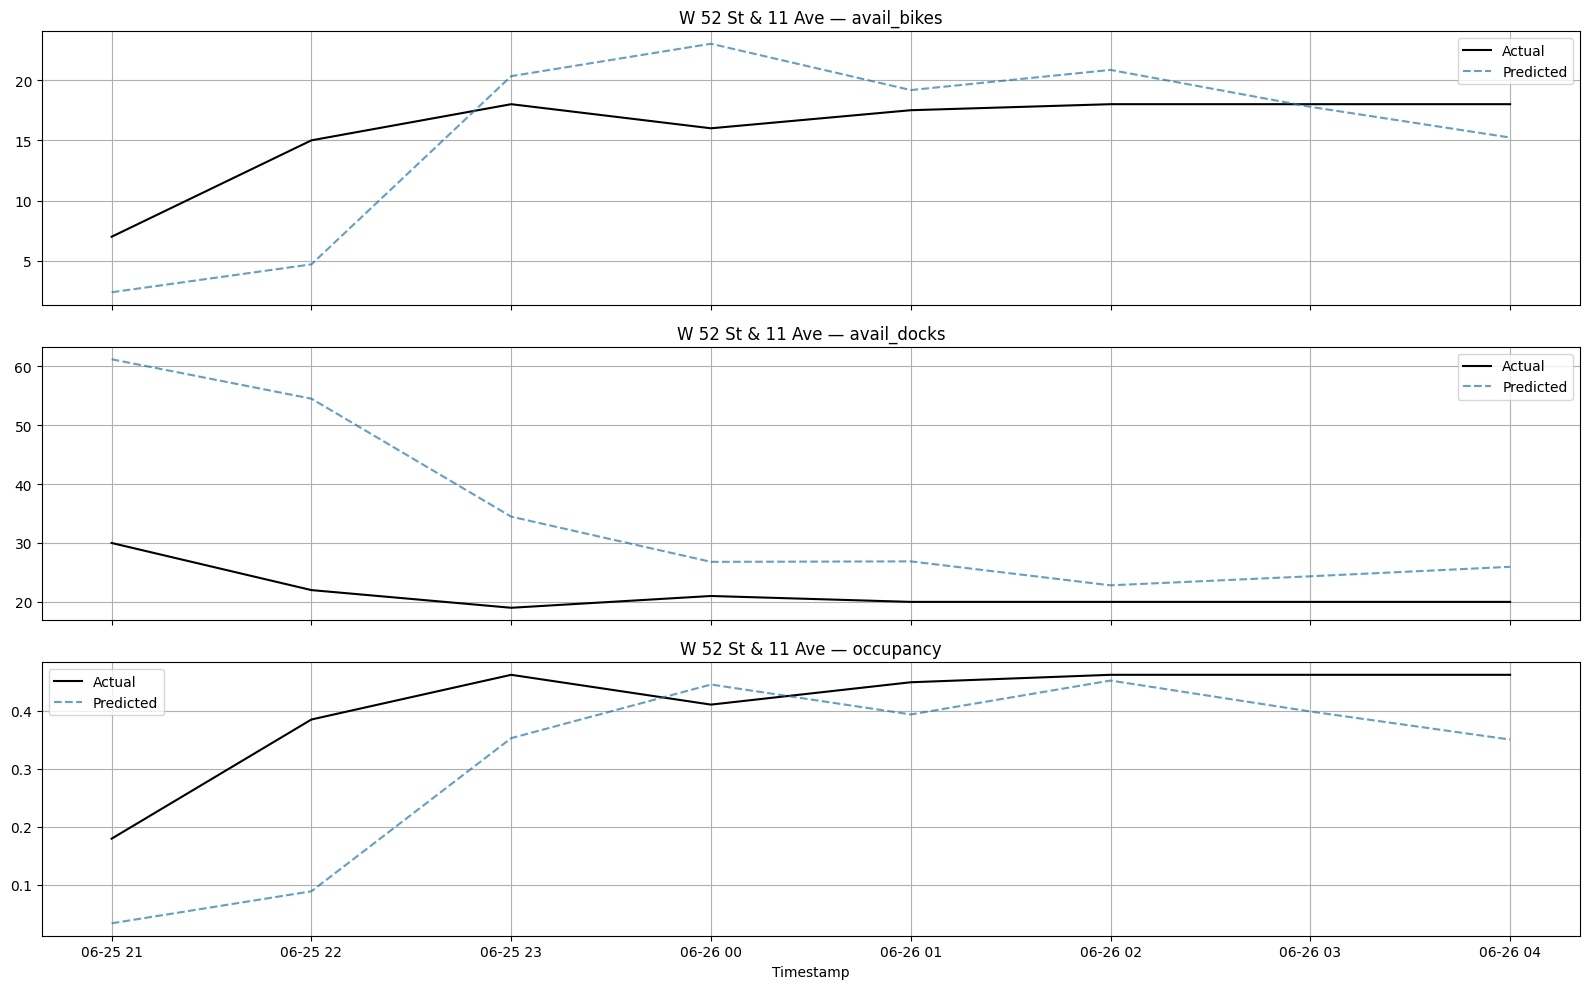

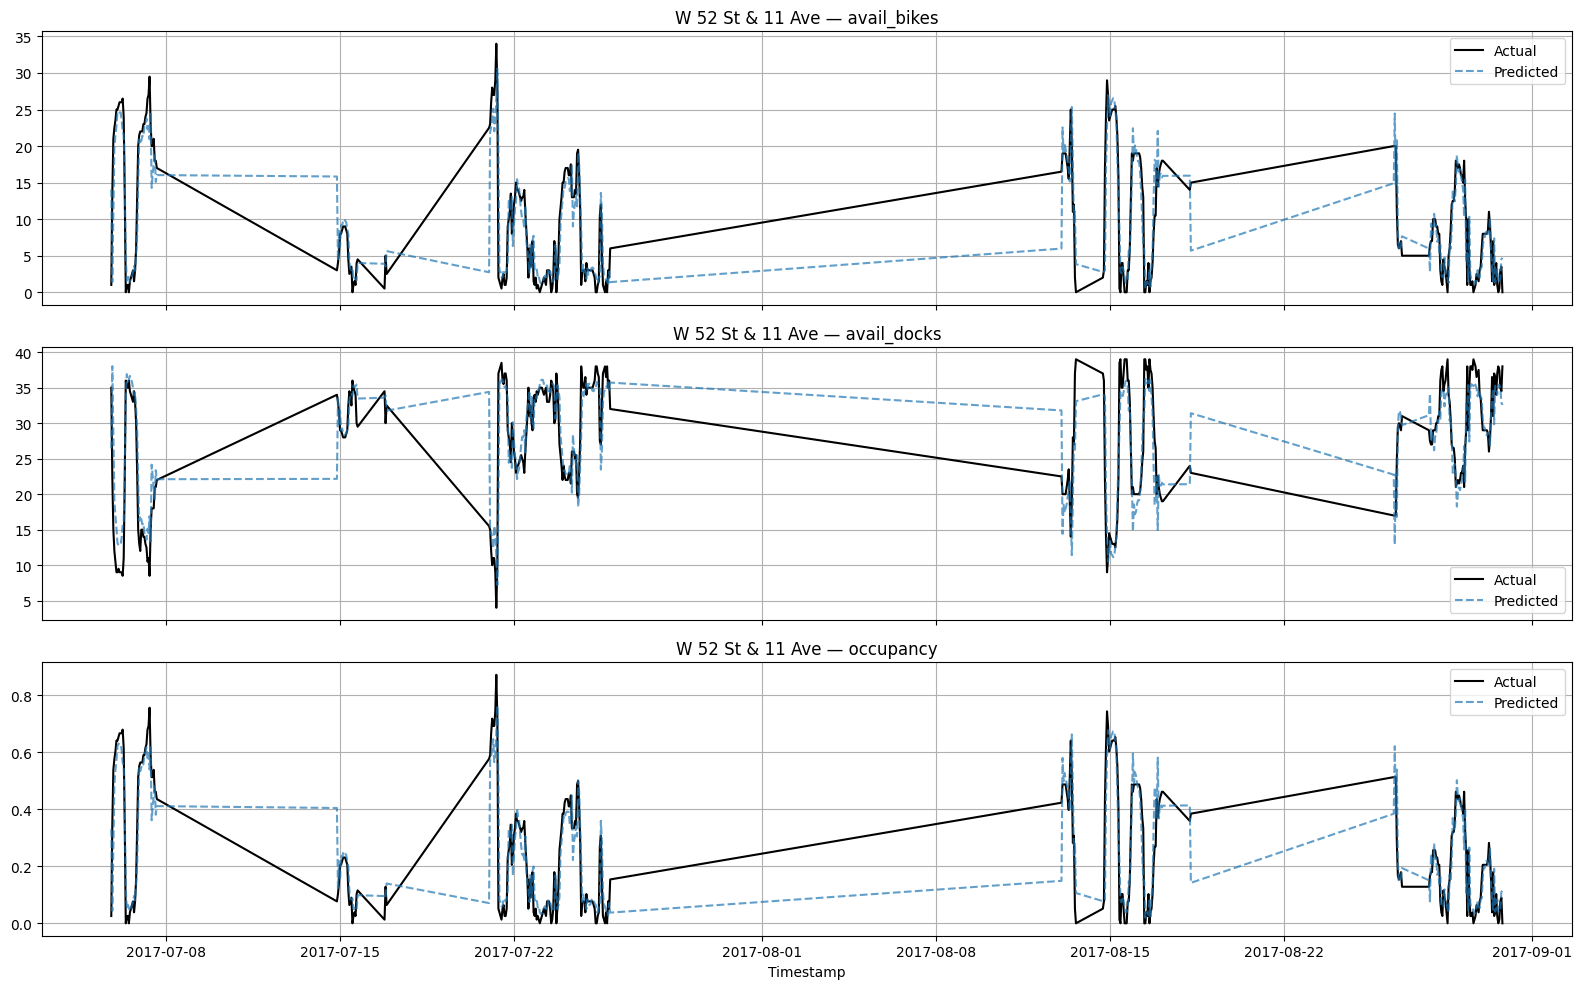

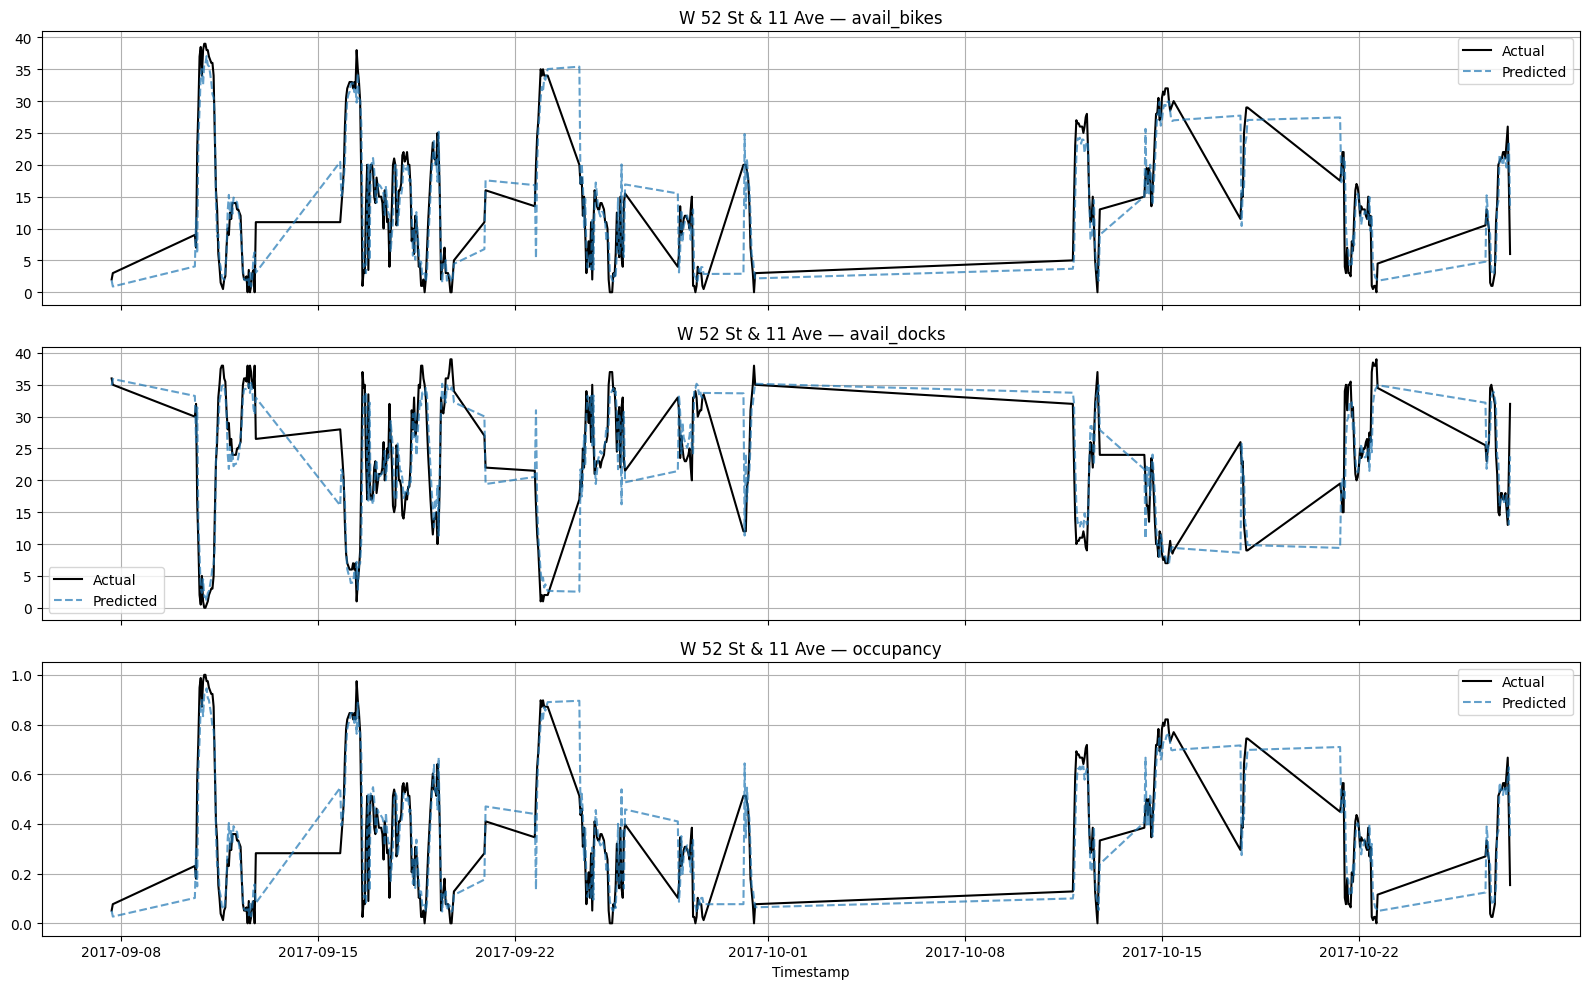

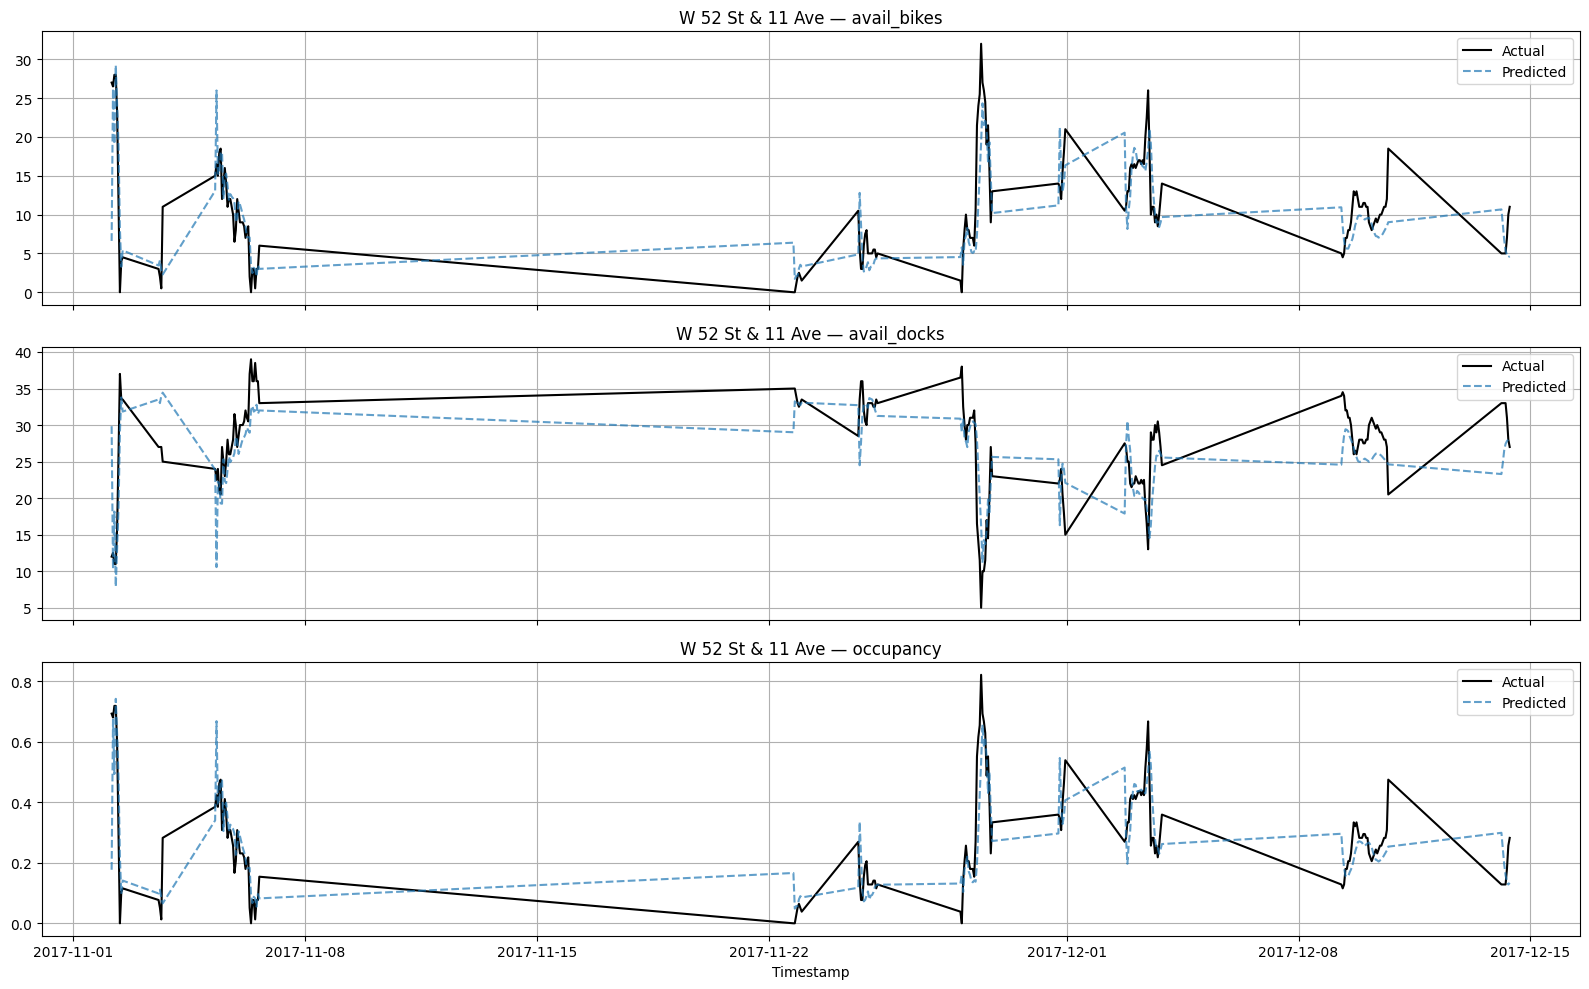

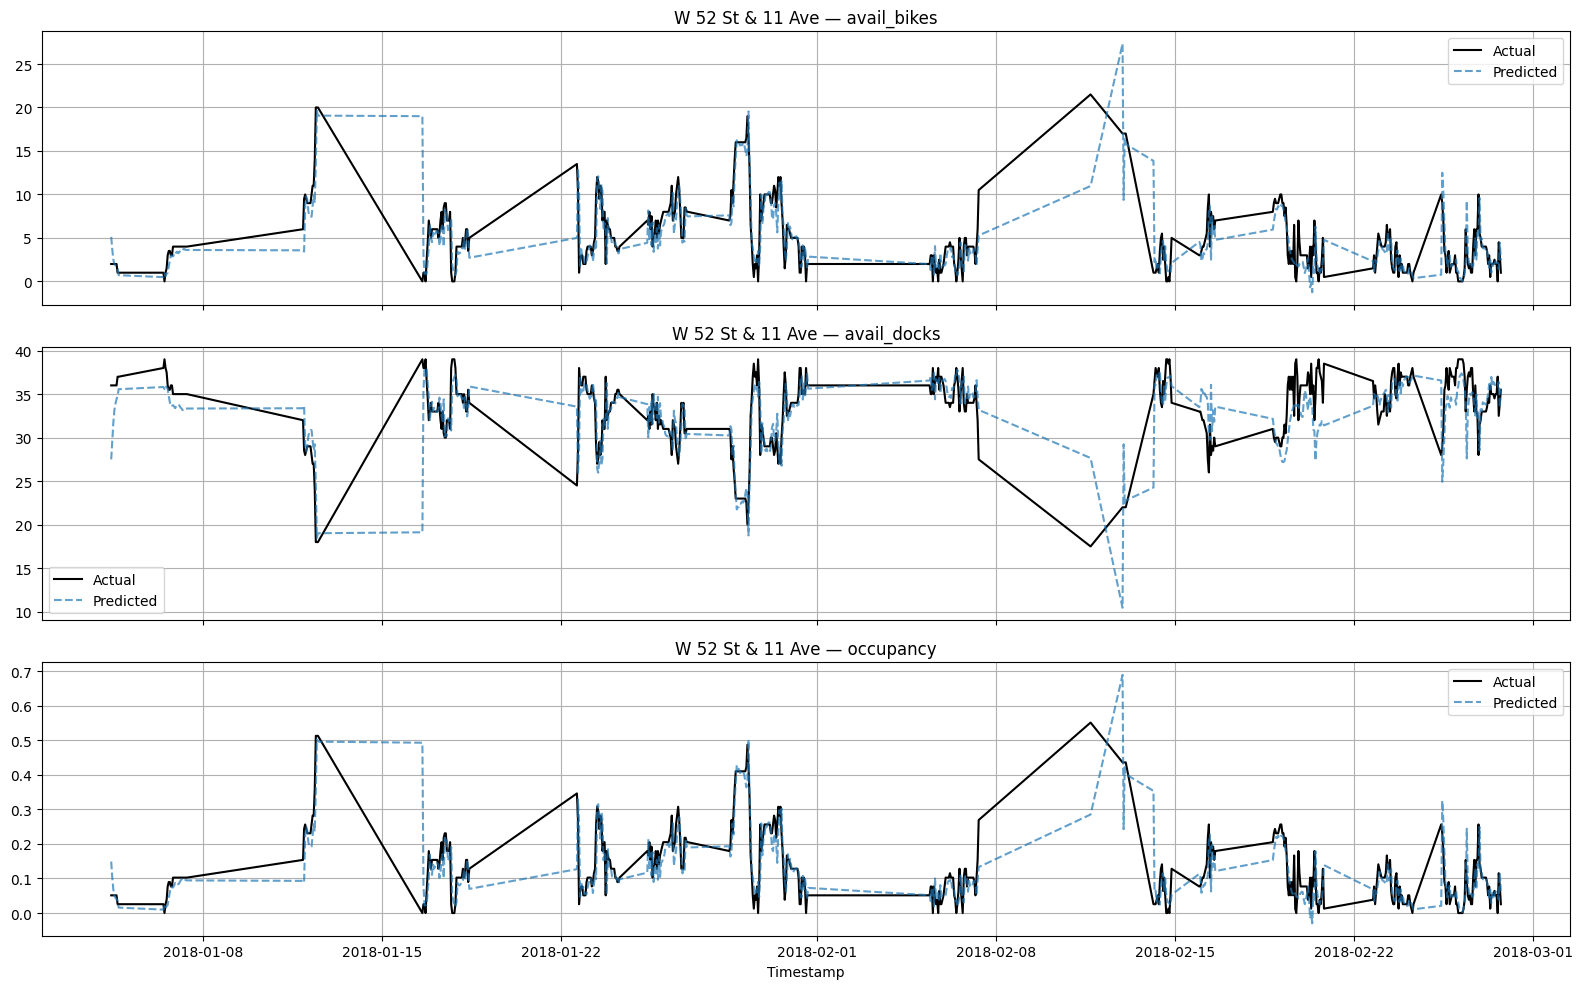

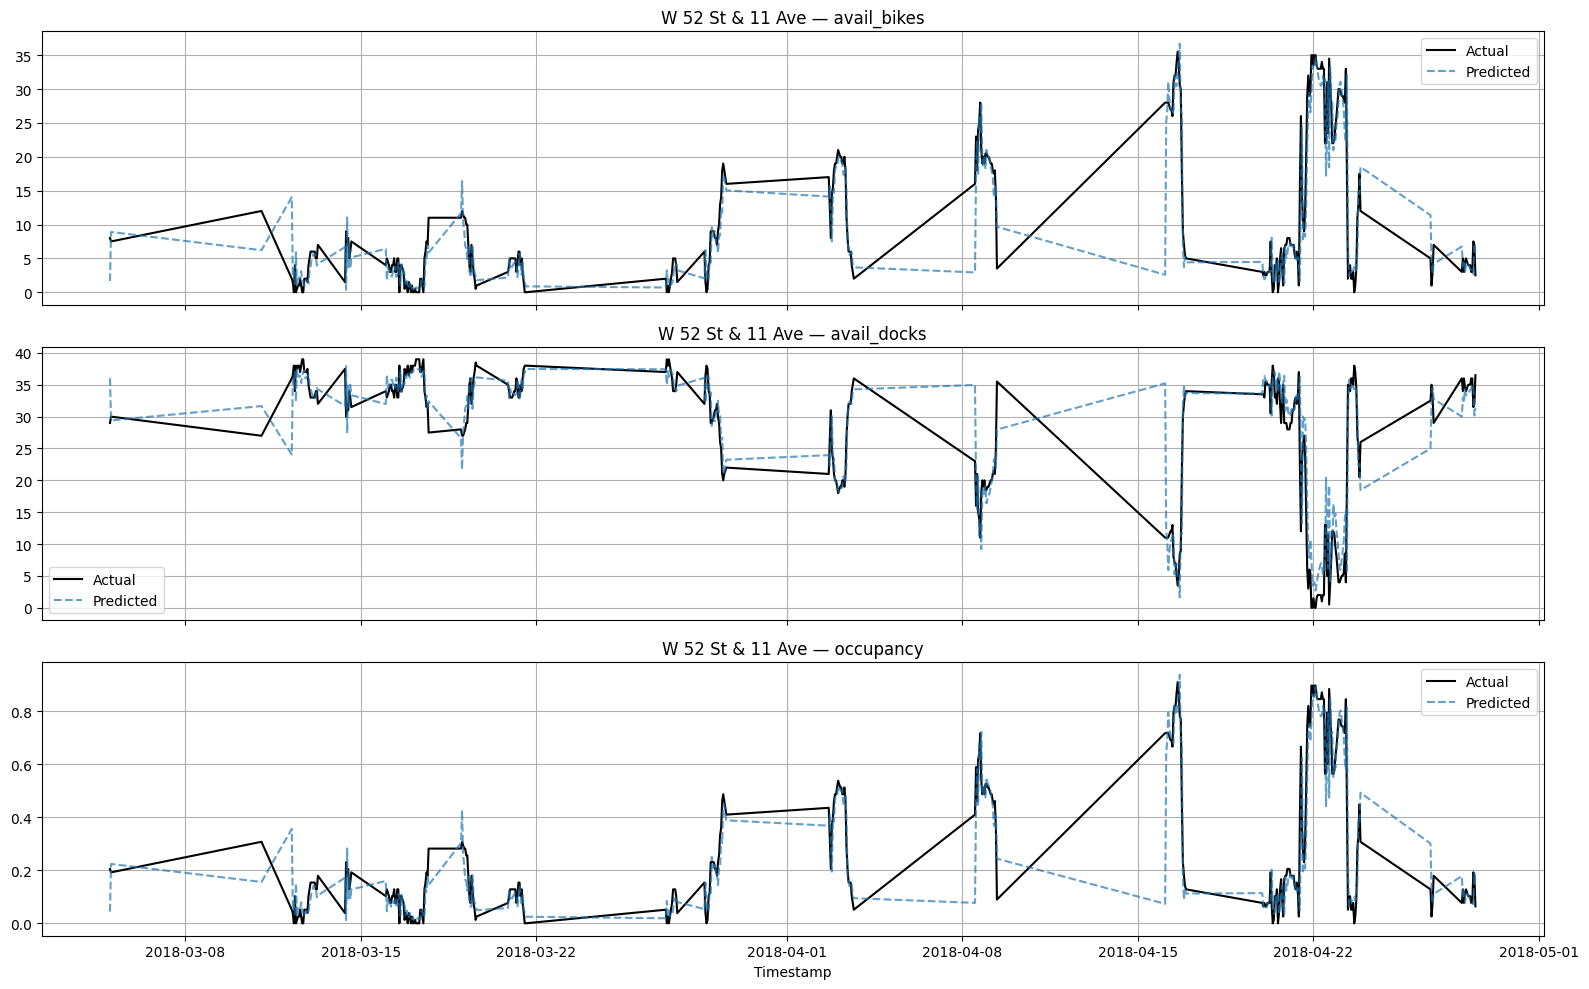

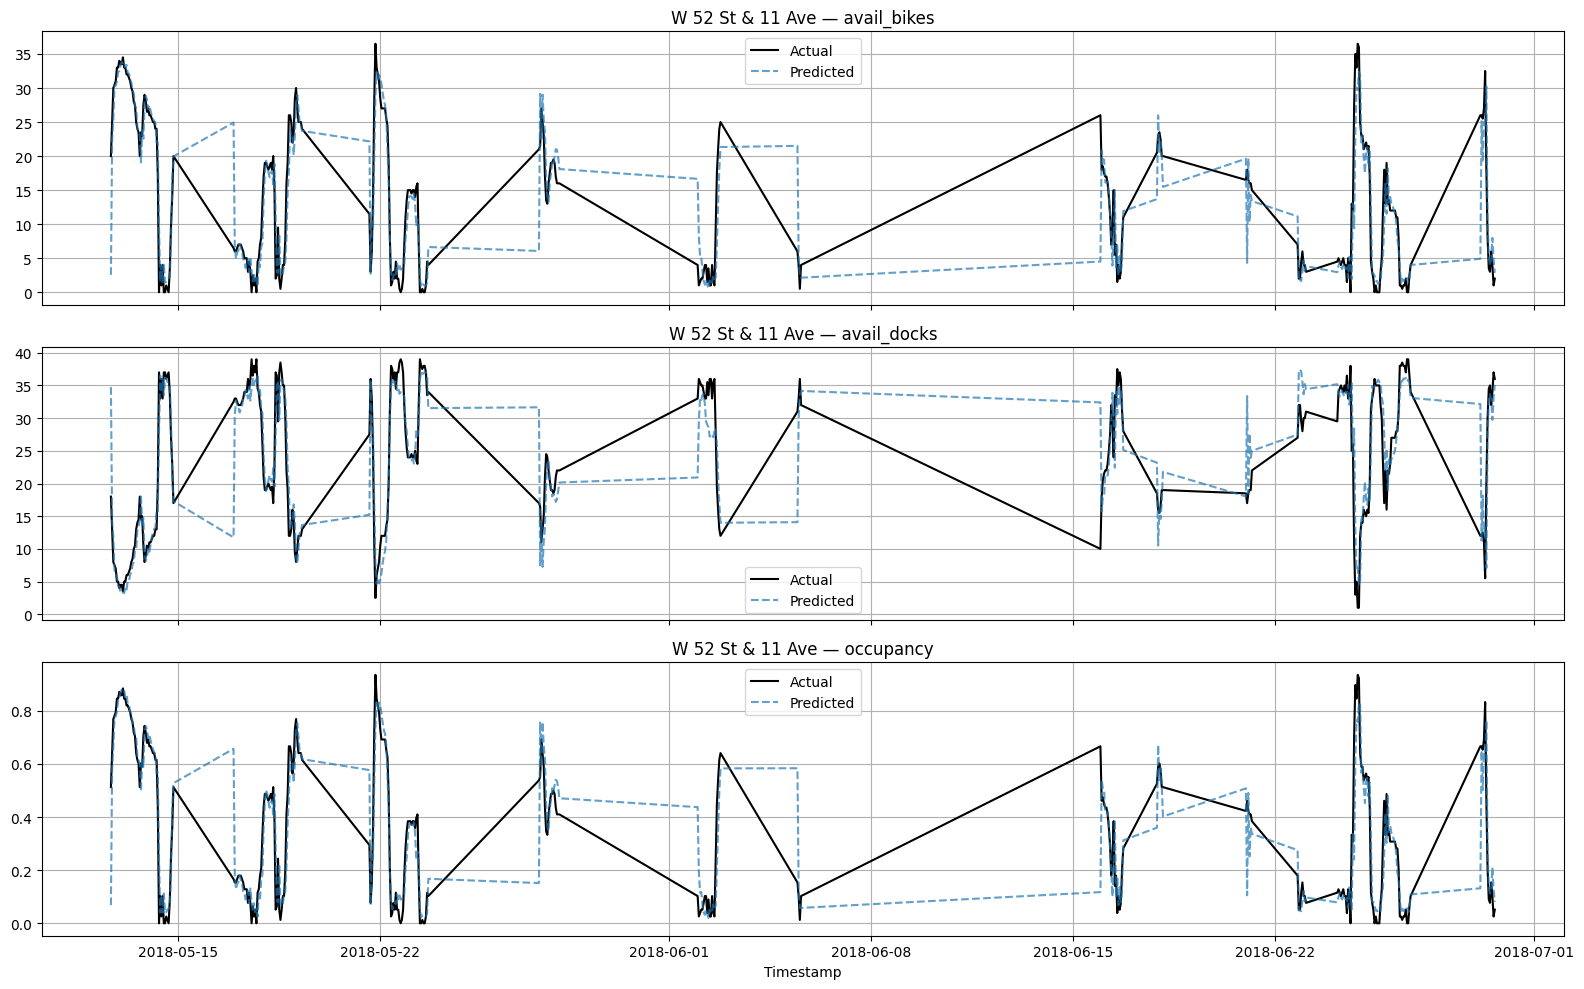

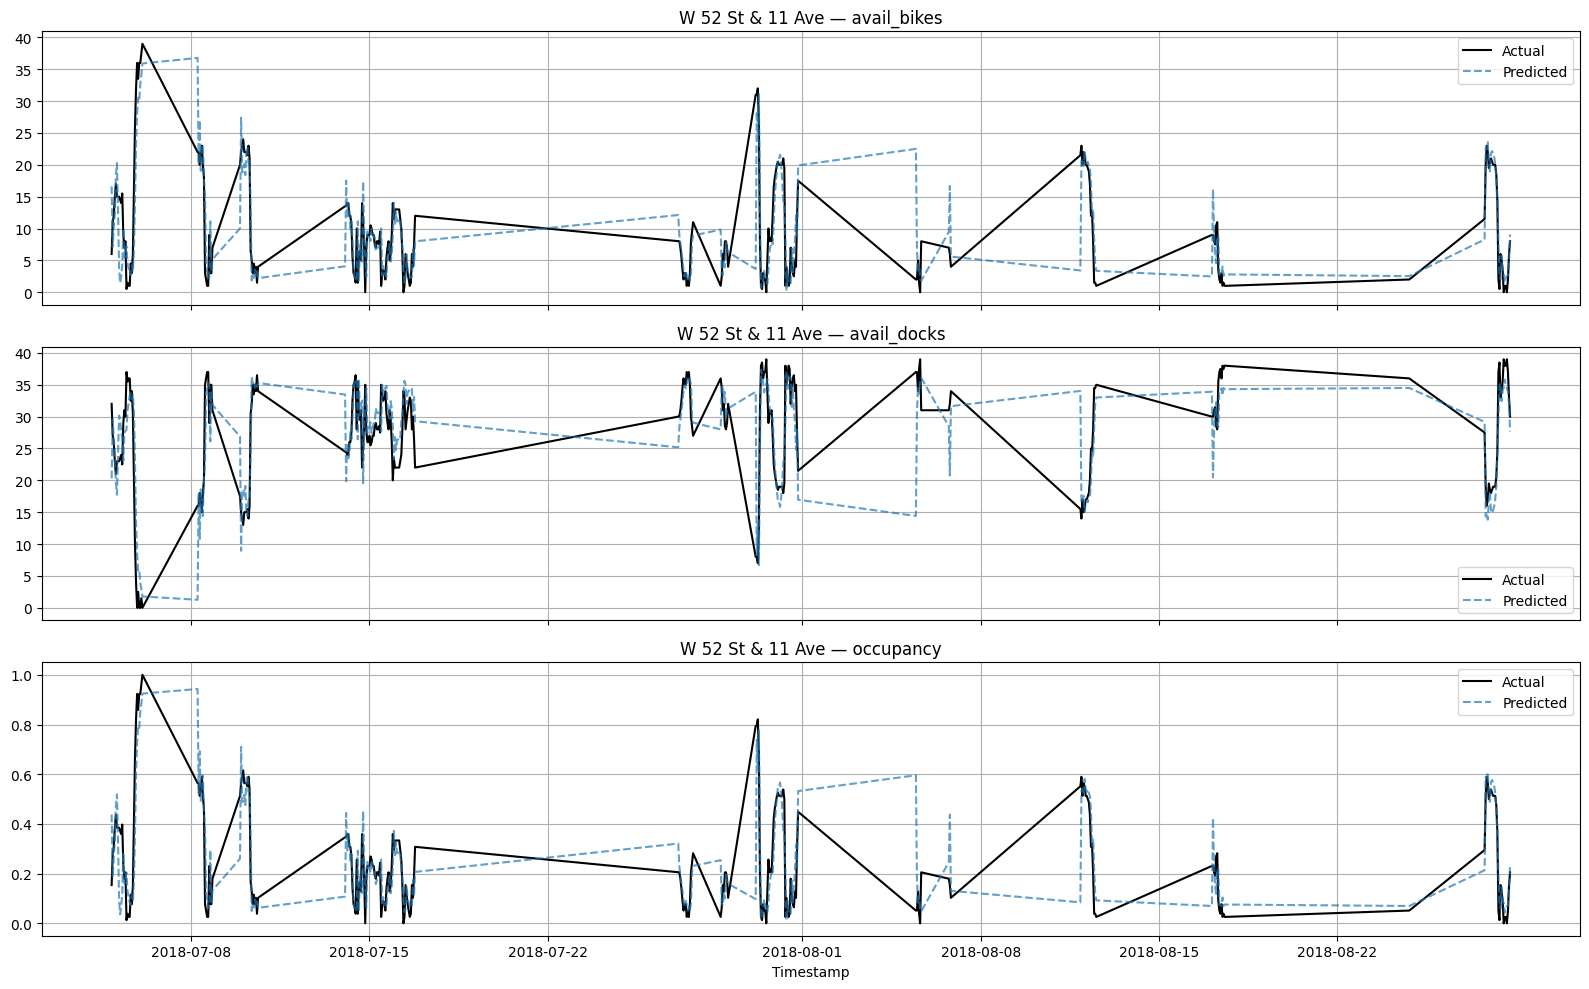

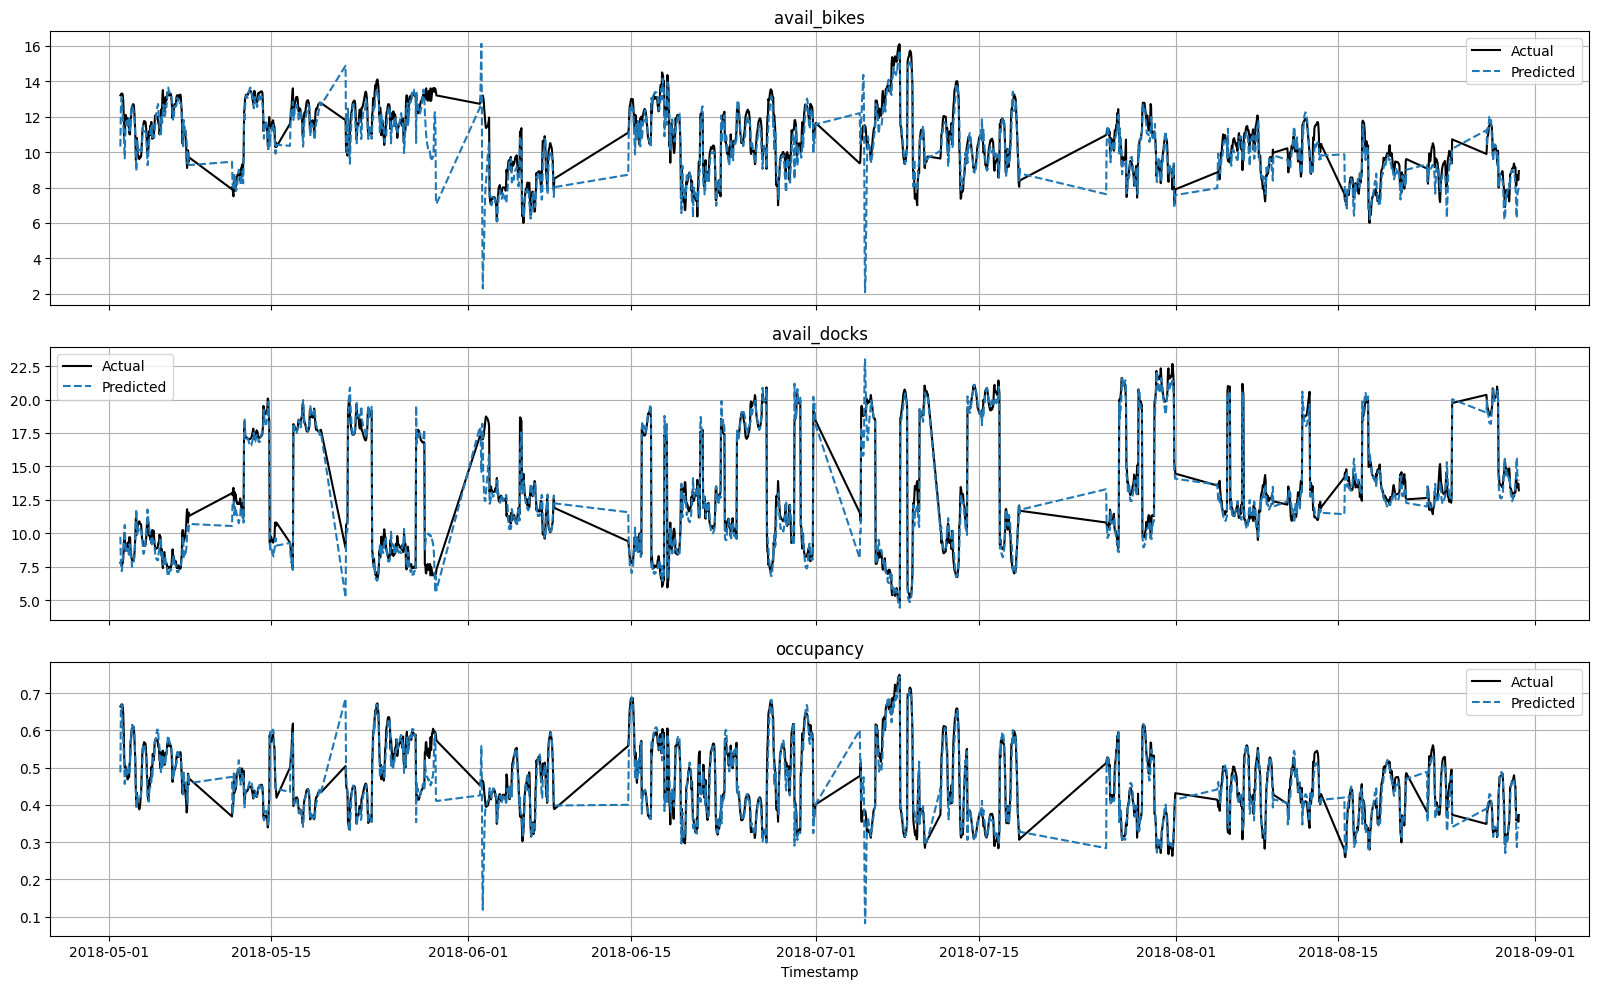

/tmp/ipython-input-387469044.py:172: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/wandb/sdk/data_types/image.py:407: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  util.ensure_matplotlib_figure(data).savefig(buf, format=self.format)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


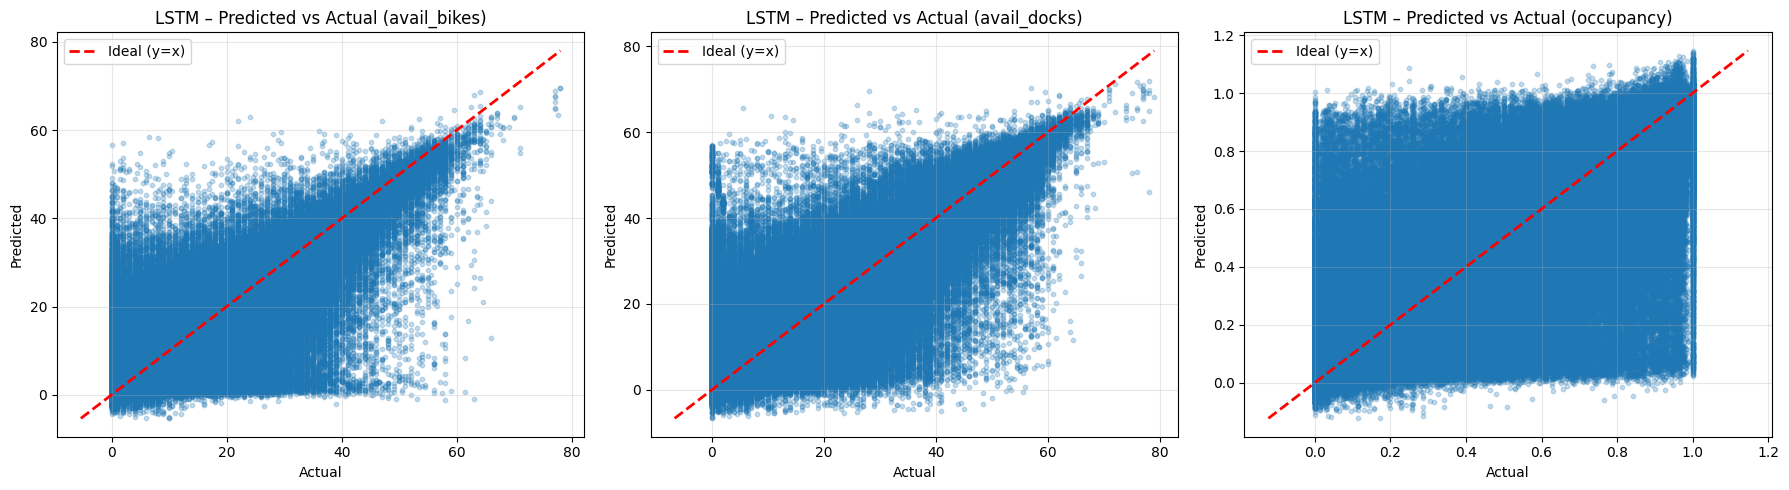

In [ ]:
# ============================================================
# 11. VISUALIZATIONS (MATCHING XGBOOST STYLE)
# ============================================================

import matplotlib.dates as mdates

# ----------------------------------------------
# Correct timestamp alignment for LSTM windows
# ----------------------------------------------
timestamps_aligned = test_df["timestamp"].iloc[WINDOW:].reset_index(drop=True)
y_true_df = pd.DataFrame(y_true, columns=TARGETS)
y_pred_df = pd.DataFrame(y_pred, columns=TARGETS)


# ============================================================
# A. TIME-SERIES PLOTS
# ============================================================

def plot_actual_vs_pred_time_station(
    test_df,
    y_true,
    y_pred,
    dock_name="W 52 St & 11 Ave",
    start=None,
    end=None
):
    # Filter station
    mask = test_df["dock_name"] == dock_name
    if mask.sum() == 0:
        raise ValueError(f"No data found for station: {dock_name}")

    timestamps = pd.to_datetime(test_df.loc[mask, "timestamp"]).reset_index(drop=True)
    y_true_s = y_true.loc[mask].reset_index(drop=True)
    y_pred_s = y_pred.loc[mask].reset_index(drop=True)

    # Time window
    if start: start = pd.to_datetime(start)
    if end:   end   = pd.to_datetime(end)

    if start or end:
        time_mask = (
            (timestamps >= start if start else True) &
            (timestamps <= end if end else True)
        )
        timestamps = timestamps[time_mask].reset_index(drop=True)
        y_true_s = y_true_s.loc[time_mask].reset_index(drop=True)
        y_pred_s = y_pred_s.loc[time_mask].reset_index(drop=True)

    # Plot
    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    for i, col in enumerate(TARGETS):
        axes[i].plot(timestamps, y_true_s[col].values, label="Actual", color="black")
        axes[i].plot(timestamps, y_pred_s[col].values, label="Predicted",
                     linestyle="--", alpha=0.7)

        axes[i].set_title(f"{dock_name} — {col}")
        axes[i].grid(); axes[i].legend()

    axes[-1].set_xlabel("Timestamp")
    plt.tight_layout()
    wandb.log({
        f"station_{dock_name}_actual_vs_pred_{start.date() if start else 'full'}_{end.date() if end else 'full'}":
        wandb.Image(fig)
    })
    plt.show()




# Example time ranges (same as XGBoost)
aligned_test_df = test_df.iloc[WINDOW:].reset_index(drop=True)

plot_actual_vs_pred_time_station(aligned_test_df, y_true_df, y_pred_df,
                         start="2017-05-01", end= "2017-06-30")
plot_actual_vs_pred_time_station(aligned_test_df, y_true_df, y_pred_df,
                         start="2017-07-01", end="2017-08-31")
plot_actual_vs_pred_time_station(aligned_test_df, y_true_df, y_pred_df,
                         start="2017-09-01", end="2017-10-31")
plot_actual_vs_pred_time_station(aligned_test_df, y_true_df, y_pred_df,
                         start="2017-11-01", end="2017-12-31")
plot_actual_vs_pred_time_station(aligned_test_df, y_true_df, y_pred_df,
                         start="2018-01-01", end="2018-02-28")
plot_actual_vs_pred_time_station(aligned_test_df, y_true_df, y_pred_df,
                         start="2018-03-01", end="2018-04-30")
plot_actual_vs_pred_time_station(aligned_test_df, y_true_df, y_pred_df,
                         start="2018-05-01", end="2018-06-30")
plot_actual_vs_pred_time_station(aligned_test_df, y_true_df, y_pred_df,
                         start="2018-07-01", end="2018-08-31")

###########################################
# B. AGGREGATE PLOTS
###########################################

def plot_actual_vs_pred_time_agg(test_df, y_true, y_pred, start=None, end=None):

    agg = test_df.copy()
    agg["pred_avail_bikes"] = y_pred[:,0]
    agg["pred_avail_docks"] = y_pred[:,1]
    agg["pred_occupancy"]   = y_pred[:,2]

    # Time filters
    if start: start = pd.to_datetime(start)
    if end:   end = pd.to_datetime(end)

    if start or end:
        agg = agg[
            (agg["timestamp"] >= start if start else True) &
            (agg["timestamp"] <= end if end else True)
        ]

    # Aggregate mean per timestamp
    grouped = (
        agg.groupby("timestamp")[[
            "avail_bikes", "pred_avail_bikes",
            "avail_docks", "pred_avail_docks",
            "occupancy", "pred_occupancy"
        ]]
        .mean()
        .reset_index()
    )

    # Plot
    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
    pairs = [
        ("avail_bikes", "pred_avail_bikes"),
        ("avail_docks", "pred_avail_docks"),
        ("occupancy", "pred_occupancy")
    ]

    for ax, (actual, pred) in zip(axes, pairs):
        ax.plot(grouped["timestamp"], grouped[actual], label="Actual", color="black")
        ax.plot(grouped["timestamp"], grouped[pred], label="Predicted", linestyle="--")
        ax.set_title(actual); ax.grid(); ax.legend()

    axes[-1].set_xlabel("Timestamp")
    plt.tight_layout()
    wandb.log({"aggregate_ts": wandb.Image(fig)})
    plt.show()

plot_actual_vs_pred_time_agg(
    test_df=aligned_test_df,
    y_true=y_test,
    y_pred=y_pred,
    start="2018-05-01",
    end="2018-08-31"
)


# ============================================================
# C. SCATTER PLOT (Actual vs Predicted)
# ============================================================

def plot_pred_vs_actual_scatter(y_true, y_pred):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for i, col in enumerate(TARGETS):
        axes[i].scatter(y_true[col], y_pred[col], alpha=0.25, s=10)

        min_val = min(y_true[col].min(), y_pred[col].min())
        max_val = max(y_true[col].max(), y_pred[col].max())

        axes[i].plot([min_val, max_val], [min_val, max_val],
                     "r--", linewidth=2, label="Ideal (y=x)")

        axes[i].set_title(f"LSTM – Predicted vs Actual ({col})")
        axes[i].set_xlabel("Actual")
        axes[i].set_ylabel("Predicted")
        axes[i].legend()
        axes[i].grid(alpha=0.3)

    plt.tight_layout()
    wandb.log({"lstm_actual_vs_pred_scatter": wandb.Image(plt.gcf())})
    plt.show()


plot_pred_vs_actual_scatter(y_true_df, y_pred_df)





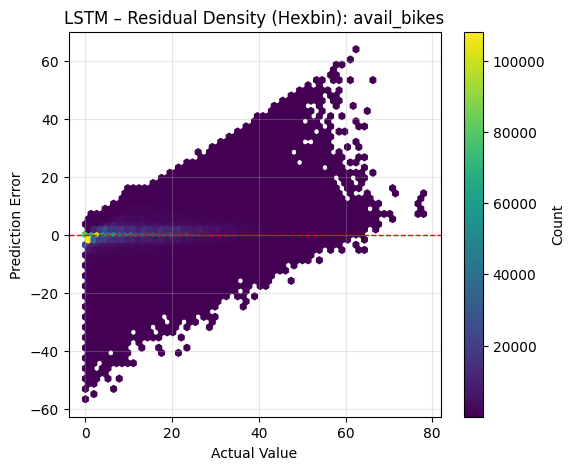

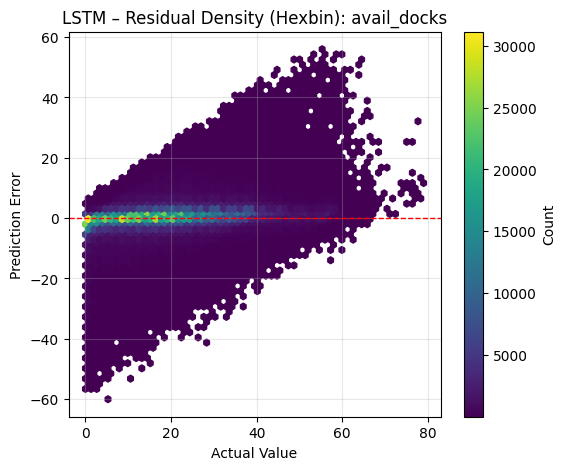

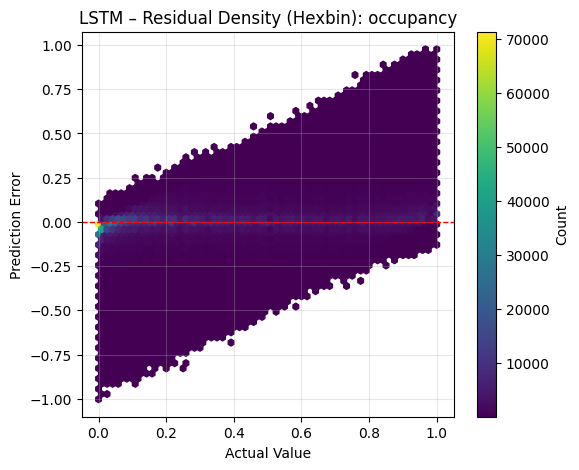

In [ ]:
# ============================================================
# C. RESIDUAL HEATMAP
# Hexbin Residual Heatmap (FAST + CLEAR)
# Why this is best
# Uses binning instead of KDE; O(n) complexity; Industry standard for regression diagnostics
# ============================================================

def plot_error_heatmap_fast(y_true, y_pred, gridsize=60):
    for col in TARGETS:
        residuals = y_true[col] - y_pred[col]

        plt.figure(figsize=(6, 5))
        plt.hexbin(
            y_true[col],
            residuals,
            gridsize=gridsize,
            cmap="viridis",
            mincnt=1
        )
        plt.colorbar(label="Count")
        plt.axhline(0, color="red", linestyle="--", linewidth=1)

        plt.title(f"LSTM – Residual Density (Hexbin): {col}")
        plt.xlabel("Actual Value")
        plt.ylabel("Prediction Error")
        plt.grid(alpha=0.3)

        wandb.log({f"lstm_residual_hexbin_{col}": wandb.Image(plt.gcf())})
        plt.show()

plot_error_heatmap_fast(y_true_df, y_pred_df)

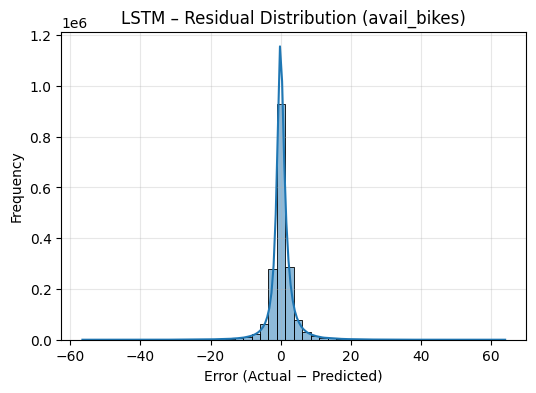

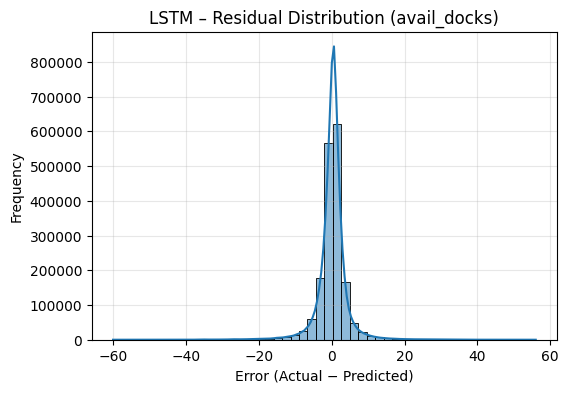

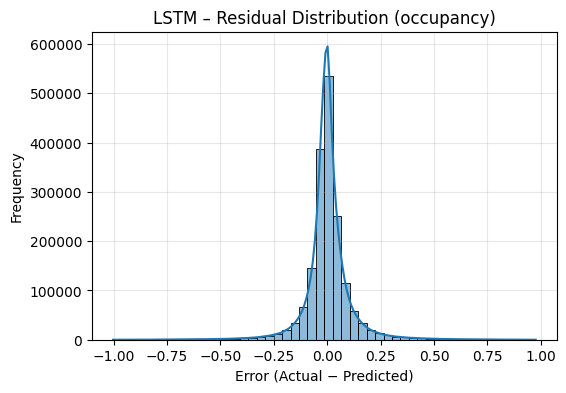


Top 5 Best Predictions (Occupancy):
                       dock_name           timestamp       _lat      _long  \
1688510       W 95 St & Broadway 2018-05-14 00:00:00  40.793770 -73.971888   
251944               Astor Place 2019-04-11 01:00:00  40.719282 -74.071262   
251945               Astor Place 2019-04-11 02:00:00  40.719282 -74.071262   
60443               2 Ave & 9 St 2019-04-29 05:00:00  40.672481 -73.993314   
1277360  Nassau Ave & Russell St 2018-10-10 04:00:00  40.725570 -73.944340   

         avail_bikes  avail_docks  tot_docks  occupancy  is_holiday  \
1688510         13.0         18.0       32.0    0.40625         0.0   
251944          14.0          0.0       14.0    1.00000         0.0   
251945          14.0          0.0       14.0    1.00000         0.0   
60443           19.0          0.0       19.0    1.00000         0.0   
1277360         21.0          2.0       24.0    0.87500         0.0   

         is_weekend  ...  hour  dayofweek  month  lag_occ_1  lag_oc

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


In [ ]:

# ============================================================
# D. RESIDUAL DISTRIBUTION
# ============================================================

def plot_residual_distribution(y_true, y_pred):
    for col in TARGETS:
        residuals = y_true[col] - y_pred[col]

        plt.figure(figsize=(6, 4))
        sns.histplot(residuals, bins=50, kde=True)
        plt.title(f"LSTM – Residual Distribution ({col})")
        plt.xlabel("Error (Actual − Predicted)")
        plt.ylabel("Frequency")
        plt.grid(alpha=0.3)

        wandb.log({
            f"lstm_residual_hist_{col}": wandb.Image(plt.gcf()),
            f"lstm_residual_histogram_raw_{col}": wandb.Histogram(residuals)
        })

        plt.show()


plot_residual_distribution(y_true_df, y_pred_df)


# ============================================================
# E. TOP-20 BEST & WORST PREDICTIONS
# ============================================================

def top_worst(X_raw, y_true, y_pred, target_idx, n=20):
    df = X_raw.iloc[WINDOW:].copy()  # align with windowing
    df["actual"] = y_true.iloc[:, target_idx].values
    df["pred"]   = y_pred.iloc[:, target_idx].values
    df["error"]  = np.abs(df["actual"] - df["pred"])
    return df.sort_values("error").head(n), df.sort_values("error", ascending=False).head(n)


# Example for occupancy (index=2)
top20, worst20 = top_worst(test_df.reset_index(drop=True), y_true_df, y_pred_df, target_idx=2)

print("\nTop 5 Best Predictions (Occupancy):")
print(top20.head())

print("\nTop 5 Worst Predictions (Occupancy):")
print(worst20.head())



In [ ]:



# ============================================================
# F. W&B TABLE OF 2000 EXAMPLES
# ============================================================

table = wandb.Table(columns=[
    "avail_bikes_actual", "avail_bikes_pred",
    "avail_docks_actual", "avail_docks_pred",
    "occupancy_actual",   "occupancy_pred"
])

for i in range(min(2000, len(y_true_df))):
    table.add_data(
        y_true_df.iloc[i, 0], y_pred_df.iloc[i, 0],
        y_true_df.iloc[i, 1], y_pred_df.iloc[i, 1],
        y_true_df.iloc[i, 2], y_pred_df.iloc[i, 2],
    )

wandb.log({"lstm_predictions_sample": table})

In [ ]:
# 13. BEST/WORST PREDICTIONS
errors = np.abs(y_true - y_pred)
worst_idx = np.argsort(errors[:,2])[-20:]
best_idx  = np.argsort(errors[:,2])[:20]

print("Worst 20 (avail_bikes):")
print(pd.DataFrame({
    "true": y_true[worst_idx,0],
    "pred": y_pred[worst_idx,0],
    "error": errors[worst_idx,0]
}))

print("Best 20 (avail_bikes):")
print(pd.DataFrame({
    "true": y_true[best_idx,0],
    "pred": y_pred[best_idx,0],
    "error": errors[best_idx,0]
}))

print("Worst 20 (avail_docks):")
print(pd.DataFrame({
    "true": y_true[worst_idx,1],
    "pred": y_pred[worst_idx,1],
    "error": errors[worst_idx,1]
}))

print("Best 20 (avail_docks):")
print(pd.DataFrame({
    "true": y_true[best_idx,1],
    "pred": y_pred[best_idx,1],
    "error": errors[best_idx,1]
}))

print("Worst 20 (occupancy):")
print(pd.DataFrame({
    "true": y_true[worst_idx,2],
    "pred": y_pred[worst_idx,2],
    "error": errors[worst_idx,2]
}))

print("Best 20 (occupancy):")
print(pd.DataFrame({
    "true": y_true[best_idx,2],
    "pred": y_pred[best_idx,2],
    "error": errors[best_idx,2]
}))


Worst 20 (avail_bikes):
    true       pred      error
0   37.0  -0.529297  37.529297
1   36.0   1.462891  34.537109
2   41.0   1.283203  39.716797
3    1.0   0.978516   0.021484
4    0.0  23.843750  23.843750
5   23.0   0.931641  22.068359
6   29.0  -0.123230  29.123230
7    0.0  25.656250  25.656250
8   25.0   1.173828  23.826172
9    0.0  17.921875  17.921875
10   0.0  17.687500  17.687500
11  27.0   0.673828  26.326172
12  20.0   0.572266  19.427734
13  21.0   0.712891  20.287109
14   0.0  41.562500  41.562500
15  25.0   0.681641  24.318359
16   0.0  27.281250  27.281250
17   1.0  30.546875  29.546875
18   0.0  56.562500  56.562500
19   0.0  34.812500  34.812500
Best 20 (avail_bikes):
    true       pred     error
0   13.0  12.882812  0.117188
1   14.0  13.859375  0.140625
2   14.0  13.820312  0.179688
3   19.0  18.734375  0.265625
4   21.0  19.828125  1.171875
5    7.0   6.554688  0.445312
6    7.0   6.945312  0.054688
7   29.0  28.312500  0.687500
8    7.0   7.039062  0.039062
9 

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


In [ ]:
# ============================================================
# 12. FINISH
# ============================================================

wandb.finish()
print("LSTM pipeline completed successfully")

epoch/epoch,▁▂▂▃▃▄▅▅▆▆▇▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▃▂▂▂▁▁▁▁▁▁▁▁
epoch/mae,█▄▃▂▂▂▁▁▁▁▁▁▁
epoch/val_loss,█▄▂▁▁▁▁▁▁▁▁▁▁
epoch/val_mae,█▄▂▁▁▁▁▁▁▁▁▁▁
lstm_avail_bikes_MAE,▁
lstm_avail_bikes_MAPE,▁
lstm_avail_bikes_R2,▁
lstm_avail_bikes_RMSE,▁
+8,...


LSTM pipeline completed successfully


In [ ]:
# artifact = run.use_artifact("lstm-multioutput-model:latest")
# artifact_dir = artifact.download()

# #Inference:
# model = tf.keras.models.load_model(f"{artifact_dir}/lstm_multioutput.keras")
# x_scaler = joblib.load(f"{artifact_dir}/lstm_x_scaler.pkl")
# y_scaler = joblib.load(f"{artifact_dir}/lstm_y_scaler.pkl")

# y_pred = model.predict(X_new)
